# N-Gram Analysis

## 1. Setup & Installation

In [33]:
# Install required libraries
!pip install nltk Sastrawi matplotlib seaborn pandas -q


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import pandas as pd
import numpy as np
import re
import string
from collections import Counter

import nltk
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Load Dataset

In [35]:
path = "../outputs/dataset_preprocessed.csv"
df = pd.read_csv(path)

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print()
df.head()

Dataset shape: 999 rows, 7 columns
Columns: ['no', 'url', 'judul', 'konten', 'manual sentiment', 'konten_length', 'konten_preprocessed']



,no,url,judul,konten,manual sentiment,konten_length,konten_preprocessed
0,1,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,8326,indonesia amerika serikat resmi milik presiden...
1,2,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,2925,indonesia nilai tukar rupiah dolar amerika ser...
2,3,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,13102,indonesia pasar uang indonesia kuat lantik don...
3,4,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,5158,indonesia indeks harga saham gabung ihsg ambru...
4,5,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,4767,hargabitcoin btc lewat angka tinggi kisara pic...


In [36]:
# Quick data overview
print("DATASET INFO")
print(f"Total articles   : {len(df)}")
print(f"Missing 'Konten' : {df['konten_preprocessed'].isna().sum()}")
print()

DATASET INFO
Total articles   : 999
Missing 'Konten' : 0



## 3. Article Selection

In [37]:
# ADJUST THIS: Choose your selection mode
SELECTION_MODE = "all"  # Options: "by_number", "by_sentiment", "all"

# --- If SELECTION_MODE = "by_number" ---
ARTICLE_NUMBERS = [9]  # <-- Change these numbers

# --- If SELECTION_MODE = "by_sentiment" ---
TARGET_SENTIMENT = "positif"  # <-- Change this label

if SELECTION_MODE == "by_number":
    selected_df = df[df['No'].isin(ARTICLE_NUMBERS)].copy()
    print(f"Selected {len(selected_df)} article(s) by number: {ARTICLE_NUMBERS}")

elif SELECTION_MODE == "by_sentiment":
    selected_df = df[df['Sentiment'].str.lower() == TARGET_SENTIMENT.lower()].copy()
    print(f"Selected {len(selected_df)} article(s) with sentiment: '{TARGET_SENTIMENT}'")

elif SELECTION_MODE == "all":
    selected_df = df.copy()
    print(f"Selected ALL {len(selected_df)} articles")

else:
    raise ValueError(f"Invalid SELECTION_MODE: '{SELECTION_MODE}'. Use 'by_number', 'by_sentiment', or 'all'.")

# Drop rows with empty content
selected_df = selected_df.dropna(subset=['konten_preprocessed'])
print(f"Articles with valid content: {len(selected_df)}")
print()

Selected ALL 999 articles
Articles with valid content: 999



## 4. Text Preprocessing (Bahasa Indonesia)

Preprocessing steps:
1. **Lowercase** all text
2. **Remove URLs, HTML tags, numbers, punctuation**
3. **Remove Indonesian stopwords** using Sastrawi
4. **Tokenize** into individual words
5. *(Optional)* **Stemming** using Sastrawi Indonesian stemmer

Sastrawi is used because it is specifically built for Bahasa Indonesia, unlike NLTK's default English stopwords.

In [38]:
USE_STEMMING = False  # Set True to enable stemming

# Initialize Sastrawi tools
stopword_factory = StopWordRemoverFactory()
indonesian_stopwords = set(stopword_factory.get_stop_words())

# Add custom stopwords if needed (common filler words in articles)
custom_stopwords = {
    'yang', 'dan', 'di', 'dari', 'untuk', 'pada', 'dengan',
    'ini', 'itu', 'ke', 'dalam', 'adalah', 'juga', 'tidak',
    'akan', 'ada', 'atau', 'bisa', 'sudah', 'lebih', 'oleh',
    'hal', 'saat', 'dapat', 'telah', 'mereka', 'saya', 'kami',
    'kita', 'hanya', 'seperti', 'tentang', 'antara', 'lain',
    'maka', 'jika', 'bagi', 'pun', 'lagi', 'masih', 'ia',
    'dia', 'anda', 'kata', 'ujar', 'ucap', 'tutur', 'sebut'
}
all_stopwords = indonesian_stopwords.union(custom_stopwords)

if USE_STEMMING:
    stemmer_factory = StemmerFactory()
    stemmer = stemmer_factory.createStemmer()
    print("Stemmer initialized (this may take a moment).")

print(f"Total stopwords loaded: {len(all_stopwords)}")

Total stopwords loaded: 129


In [39]:
def preprocess_text(text):
    if not isinstance(text, str):
        return []

    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)

    # Step 3: Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Step 4: Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Step 5: Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', ' ', text)

    # Step 6: Tokenize
    tokens = word_tokenize(text)

    # Step 7: Remove stopwords
    tokens = [t for t in tokens if t not in all_stopwords]

    # Step 8: Remove short tokens (likely noise)
    tokens = [t for t in tokens if len(t) >= 3]

    # Step 9: Optional stemming
    if USE_STEMMING:
        tokens = [stemmer.stem(t) for t in tokens]

    return tokens


# Apply preprocessing to selected articles
print("Preprocessing articles...")
selected_df['tokens'] = selected_df['konten_preprocessed'].apply(preprocess_text)
selected_df['token_count'] = selected_df['tokens'].apply(len)

print("Done!")
print()

# Show token counts per article
for idx, row in selected_df.iterrows():
    print(f"  [{row['no']}] {row['judul']} -> {row['token_count']} tokens")
    print(row["konten_preprocessed"])

Preprocessing articles...
Done!

  [1] Trump Sebar Exceutive Order: Emang Semengerikan Apa Buat Indonesia? - CNBC Indonesia -> 588 tokens
indonesia amerika serikat resmi milik presiden sambut positif agenda pro bisnis bawa presiden amerika serikat donald trump resmi lantik senin pidato trump bijak dagang proteksionis khawatir agresif terap ukur trump bawa agenda ambisius liput reformasi dagang imigrasi mangkas pajak deregulasi bijak potensi tingkat untung korporasi risiko picu inflasi tekan saham obligasi dorong bank sentral fed naik suku bunga executive order perintah eksekutif lansir dariabcnews trump malam presiden cabut tindak eksekutif perintah eksekutif memorandum presiden era joe biden rangkai tindak eksekutif rencana jabat trump menandatangani perintah perintah pidato raya lantik capital arena washington executive order perintah eksekutif arah resmi presiden lembaga lembaga perintah federal perintah operasi tangan isu isu perintah fungsi alat presiden kelola administrasi federa

In [40]:
# Preview tokens from the first selected article
first_article = selected_df.iloc[0]
print(f"Preview tokens from article [{first_article['no']}]:")
print(first_article['tokens'][:30])
print(f"... (total: {first_article['token_count']} tokens)")

Preview tokens from article [1]:
['indonesia', 'amerika', 'serikat', 'resmi', 'milik', 'presiden', 'sambut', 'positif', 'agenda', 'pro', 'bisnis', 'bawa', 'presiden', 'amerika', 'serikat', 'donald', 'trump', 'resmi', 'lantik', 'senin', 'pidato', 'trump', 'bijak', 'dagang', 'proteksionis', 'khawatir', 'agresif', 'terap', 'ukur', 'trump']
... (total: 588 tokens)


## 5. N-Gram Generation

In [41]:
def generate_ngrams(tokens, n):
    return list(ngrams(tokens, n))


# Combine all tokens from selected articles into one list
all_tokens = []
for tokens in selected_df['tokens']:
    all_tokens.extend(tokens)

print(f"Total combined tokens: {len(all_tokens)}")
print()

# Generate unigrams, bigrams, and trigrams
unigrams = generate_ngrams(all_tokens, 1)
bigrams  = generate_ngrams(all_tokens, 2)
trigrams = generate_ngrams(all_tokens, 3)

print(f"Unigrams generated: {len(unigrams)}")
print(f"Bigrams generated : {len(bigrams)}")
print(f"Trigrams generated: {len(trigrams)}")

Total combined tokens: 324792

Unigrams generated: 324792
Bigrams generated : 324791
Trigrams generated: 324790


---
## 6. N-Gram Frequency Analysis

We count how often each n-gram appears and rank them by frequency.

In [42]:
TOP_N = 20

unigram_freq = Counter(unigrams)
bigram_freq  = Counter(bigrams)
trigram_freq = Counter(trigrams)

def freq_to_dataframe(freq_counter, n_label):
    items = freq_counter.most_common(TOP_N)
    df_freq = pd.DataFrame(items, columns=[n_label, 'Frequency'])
    df_freq[n_label] = df_freq[n_label].apply(lambda x: ' '.join(x))
    df_freq.index = range(1, len(df_freq) + 1)  # Start index at 1
    df_freq.index.name = 'Rank'
    return df_freq


df_unigrams = freq_to_dataframe(unigram_freq, 'Unigram')
df_bigrams  = freq_to_dataframe(bigram_freq, 'Bigram')
df_trigrams = freq_to_dataframe(trigram_freq, 'Trigram')

In [43]:
print("=" * 40)
print(f"TOP {TOP_N} UNIGRAMS")
print("=" * 40)
print(df_unigrams.to_string())

TOP 20 UNIGRAMS
        Unigram  Frequency
Rank                      
1         tarif      10172
2         trump       6292
3        negara       5911
4     indonesia       5309
5        dagang       5295
6         china       3808
7        persen       3445
8         impor       3288
9       ekonomi       3123
10        bijak       3101
11      amerika       2576
12       produk       2569
13        pasar       2434
14     perintah       2357
15       barang       2194
16     presiden       2078
17       ekspor       2060
18         laku       1992
19         kena       1866
20      serikat       1803


In [44]:
print("=" * 40)
print(f"TOP {TOP_N} BIGRAMS")
print("=" * 40)
print(df_bigrams.to_string())

TOP 20 BIGRAMS
                Bigram  Frequency
Rank                             
1      amerika serikat       1747
2          bijak tarif       1136
3          tarif impor       1111
4         donald trump       1110
5           kena tarif       1089
6        negara negara       1087
7          tarif trump        925
8        perang dagang        706
9     tarif resiprokal        602
10       barang barang        596
11          naik tarif        558
12        tarif persen        528
13           bea masuk        516
14     presiden donald        490
15           uni eropa        489
16    presiden amerika        484
17       miliar dollar        481
18         terap tarif        475
19      serikat donald        447
20          laku tarif        445


In [45]:
print("=" * 40)
print(f"TOP {TOP_N} TRIGRAMS")
print("=" * 40)
print(df_trigrams.to_string())

TOP 20 TRIGRAMS
                         Trigram  Frequency
Rank                                       
1          presiden donald trump        487
2       presiden amerika serikat        466
3         amerika serikat donald        437
4           serikat donald trump        412
5              bijak tarif trump        283
6              bijak tarif impor        156
7            tarif barang barang        154
8               naik tarif impor        147
9               kena tarif impor        140
10             kena tarif persen        140
11               tarif bea masuk        137
12            nilai tukar rupiah        133
13    menteri koordinator bidang        126
14       scroll continue content        126
15    ekonomi airlangga hartarto        124
16    koordinator bidang ekonomi        121
17              trump kena tarif        115
18             donald trump umum        109
19           negara mitra dagang        108
20               bea masuk impor        107


## 7. Visualization

In [46]:
def plot_ngram(df_freq, n_label, color_palette, top_k=15):

    data = df_freq.head(top_k).iloc[::-1]

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = sns.color_palette(color_palette, len(data))

    ax.barh(data[n_label], data['Frequency'], color=colors)
    ax.set_xlabel('Frequency', fontsize=12)
    ax.set_ylabel(n_label, fontsize=12)
    ax.set_title(f'Top {top_k} Most Frequent {n_label}s', fontsize=14, fontweight='bold')

    # Add count labels on bars
    for i, (val, name) in enumerate(zip(data['Frequency'], data[n_label])):
        ax.text(val + 0.3, i, str(val), va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

PLOT_TOP_K = 15

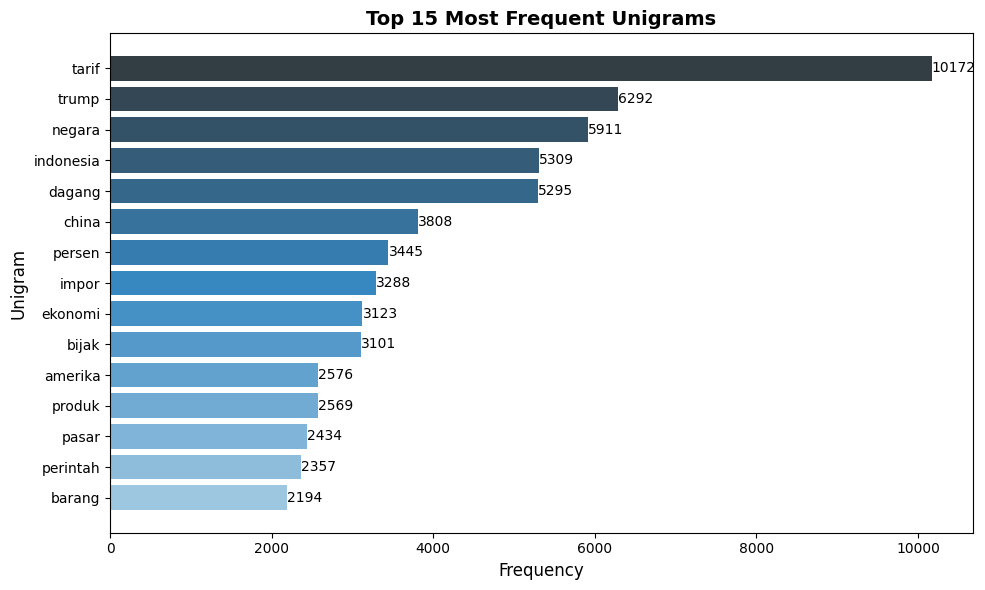

In [47]:
plot_ngram(df_unigrams, 'Unigram', 'Blues_d', PLOT_TOP_K)

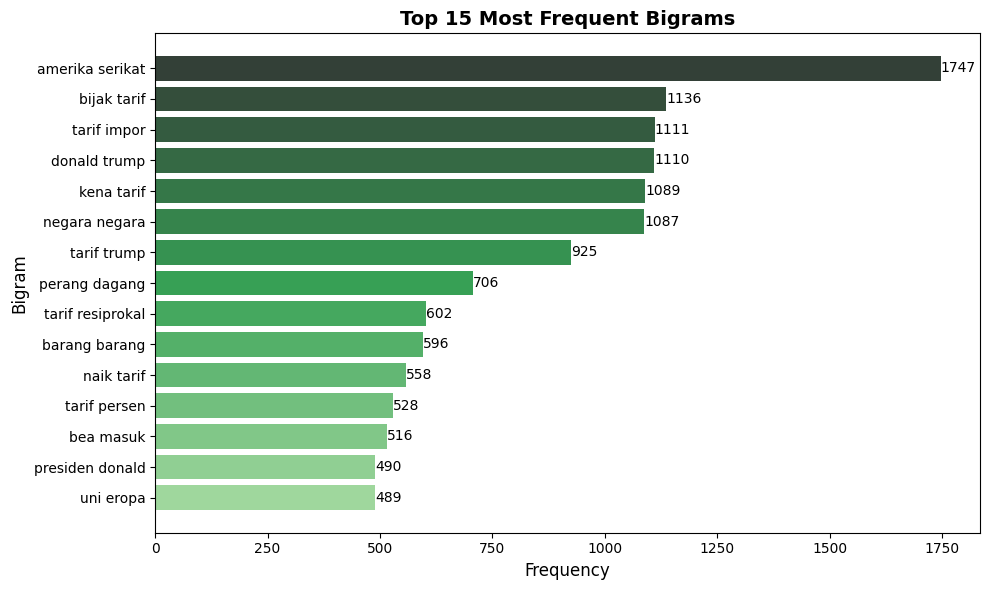

In [48]:
plot_ngram(df_bigrams, 'Bigram', 'Greens_d', PLOT_TOP_K)

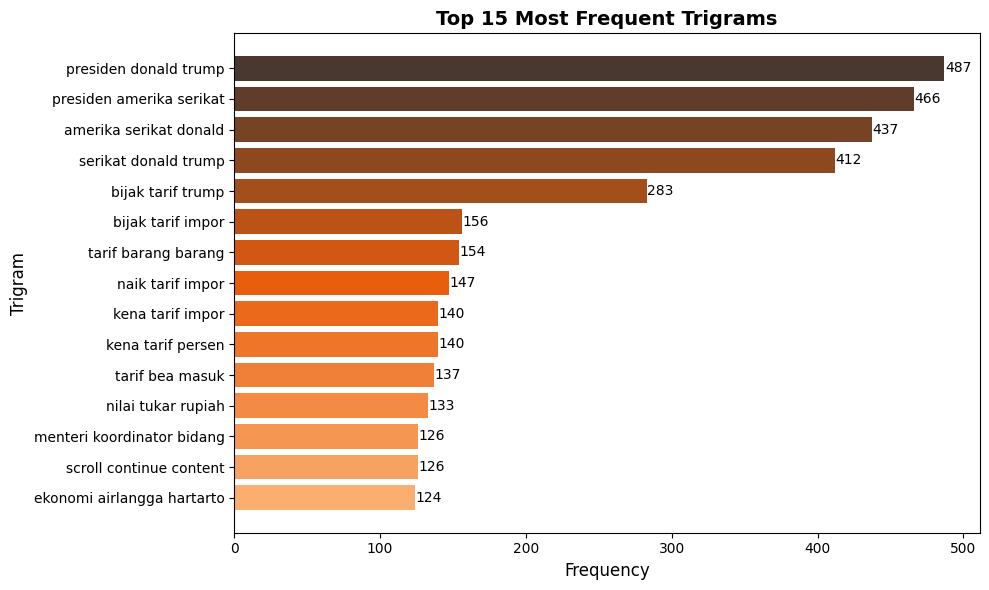

In [49]:
plot_ngram(df_trigrams, 'Trigram', 'Oranges_d', PLOT_TOP_K)

### 7.1 Combined Overview Chart

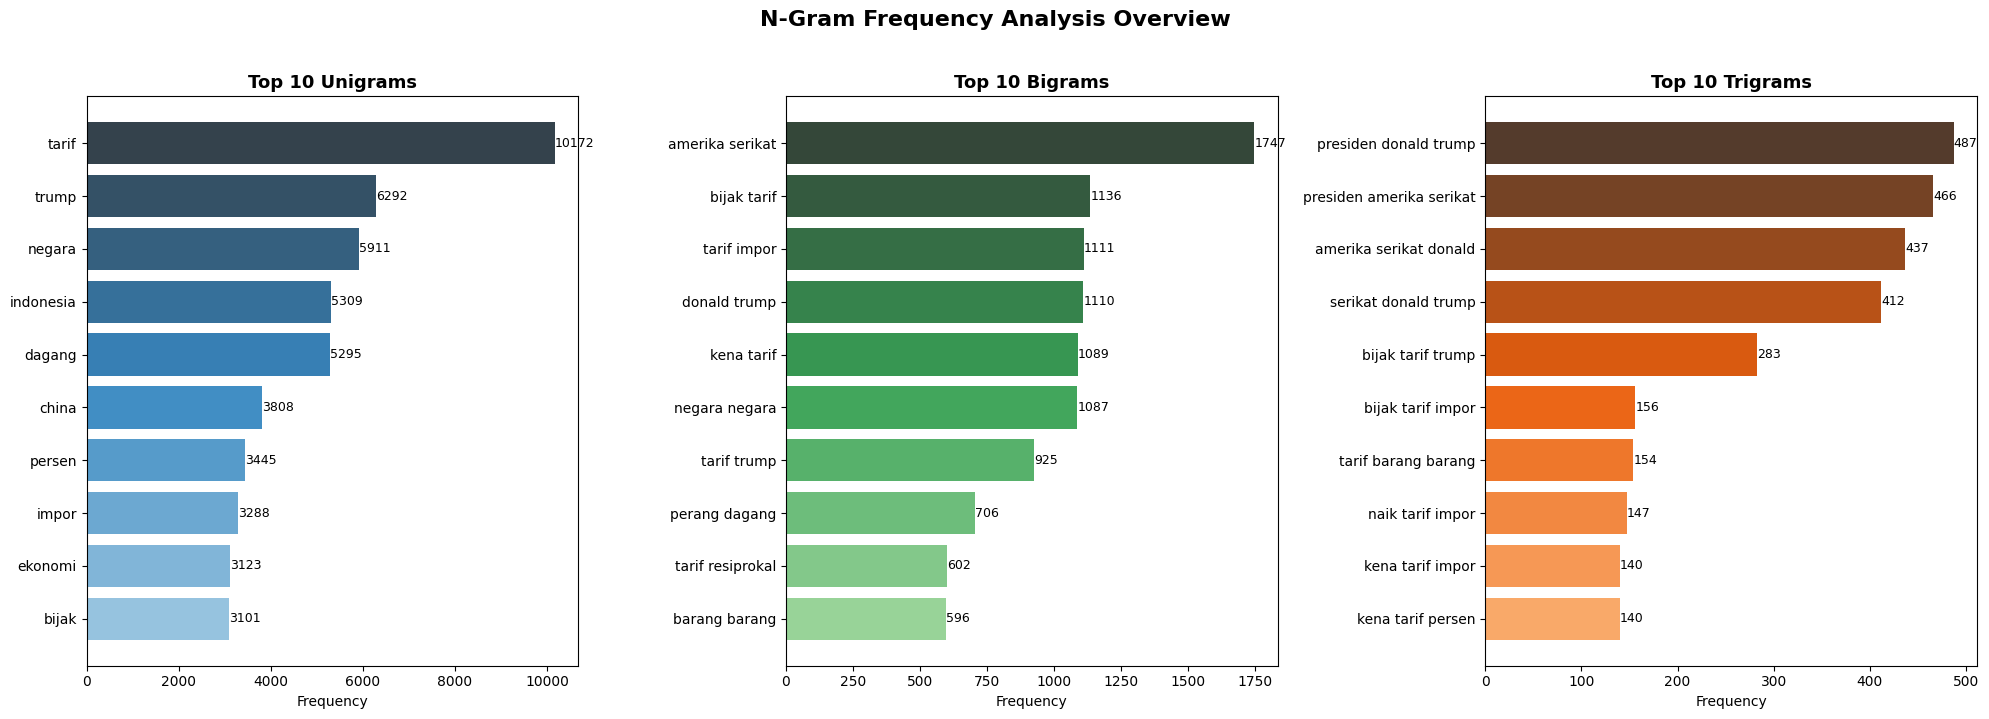

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

datasets = [
    (df_unigrams, 'Unigram', 'Blues_d'),
    (df_bigrams, 'Bigram', 'Greens_d'),
    (df_trigrams, 'Trigram', 'Oranges_d')
]

for ax, (df_freq, label, palette) in zip(axes, datasets):
    top_10 = df_freq.head(10).iloc[::-1]
    colors = sns.color_palette(palette, len(top_10))
    ax.barh(top_10[label], top_10['Frequency'], color=colors)
    ax.set_title(f'Top 10 {label}s', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')

    for i, val in enumerate(top_10['Frequency']):
        ax.text(val + 0.2, i, str(val), va='center', fontsize=9)

plt.suptitle('N-Gram Frequency Analysis Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Per-Article N-Gram Comparison (Optional)

If you selected multiple articles, this section shows the top bigrams for each article individually, so you can compare patterns across articles.

In [52]:
if len(selected_df) > 1:
    print("Per-article top 5 bigrams:")
    print("=" * 60)
    for idx, row in selected_df.iterrows():
        article_bigrams = generate_ngrams(row['tokens'], 2)
        article_bigram_freq = Counter(article_bigrams).most_common(5)
        print(f"\nArticle [{row['no']}]: {row['judul'][:60]}")
        for bg, count in article_bigram_freq:
            print(f"    {' '.join(bg):30s}  ({count}x)")
else:
    print("Only one article selected. Skipping per-article comparison.")

Per-article top 5 bigrams:

Article [1]: Trump Sebar Exceutive Order: Emang Semengerikan Apa Buat Ind
    perintah eksekutif              (5x)
    tindak eksekutif                (3x)
    harap ditandatangani            (3x)
    sumber daya                     (3x)
    daya alam                       (3x)

Article [2]: Alasan Rupiah 'Berpesta' di Pelantikan Trump, Dolar Bisa Rp1
    trump lantik                    (3x)
    barang impor                    (3x)
    trump tariff                    (3x)
    donald trump                    (2x)
    kena tarif                      (2x)

Article [3]: Trump Beri Kabar Baik, Saatnya Menunggu Dolar Eksportir Bali
    amerika serikat                 (5x)
    bijak trump                     (5x)
    lapor uang                      (5x)
    donald trump                    (4x)
    mata uang                       (4x)

Article [4]: IHSG Merah Lagi, Begini Penjelasan dari Analis! - CNBC Indon
    emiten milik                    (4x)
    berat ihsg   

In [53]:
print("=" * 60)
print("N-GRAM ANALYSIS SUMMARY")
print("=" * 60)
print(f"Articles analyzed      : {len(selected_df)}")
print(f"Total tokens (cleaned) : {len(all_tokens)}")
print(f"Unique unigrams        : {len(unigram_freq)}")
print(f"Unique bigrams         : {len(bigram_freq)}")
print(f"Unique trigrams        : {len(trigram_freq)}")
print(f"Stemming applied       : {USE_STEMMING}")
print(f"Selection mode         : {SELECTION_MODE}")
print()
print("Top 5 Bigrams:")
for bg, count in bigram_freq.most_common(5):
    print(f"    {' '.join(bg):30s}  ({count}x)")

N-GRAM ANALYSIS SUMMARY
Articles analyzed      : 999
Total tokens (cleaned) : 324792
Unique unigrams        : 13270
Unique bigrams         : 128099
Unique trigrams        : 215711
Stemming applied       : False
Selection mode         : all

Top 5 Bigrams:
    amerika serikat                 (1747x)
    bijak tarif                     (1136x)
    tarif impor                     (1111x)
    donald trump                    (1110x)
    kena tarif                      (1089x)
